# Homework 5: PCA and Eigenfaces for Face Recognition
**Name:** Aragya Goyal | **Student ID:** 4541458 | **D value:** 58

In [1]:
# Import Packages
import os
import random
import shutil
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.svm import SVC


# Define Globals
D = 58
NUM_SUBJECTS = 40
NUM_SAMPLES_PER_SUBJECT = 10

### Question 1: Data Preparation
#### Part A: Download and Split the Dataset

In [2]:
# Define Directories
all_dir = "./input/all/"
train_dir = "./input/train/"
test_dir = "./input/test/"
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Calculate number of training examples
num_train = 7 + (D % 3)

# Set random seed for reproducibility
random.seed(D)

# Split the data into training and testing sets randomly per subject
for subject in range(1, NUM_SUBJECTS + 1):
    # Define subject directory
    subject_dir = os.path.join(all_dir, f"s{subject}")

    # Create random image indices for training and testing
    all_images = list(range(1, NUM_SAMPLES_PER_SUBJECT + 1))
    random.shuffle(all_images)

    # Select training and testing images
    training_images = all_images[:num_train]
    testing_images = all_images[num_train:]

    for index in training_images:
        src_path = os.path.join(subject_dir, f"{index}.pgm")
        dst = os.path.join(train_dir, f"s{subject:02d}_{index:02d}.pgm")
        shutil.copy(src_path, dst)
    for index in testing_images:
        src_path = os.path.join(subject_dir, f"{index}.pgm")
        dst = os.path.join(test_dir, f"s{subject:02d}_{index:02d}.pgm")
        shutil.copy(src_path, dst)

# Print the number of training and testing examples
print(f"Number of training examples: {len(os.listdir(train_dir))}")
print(f"Number of testing examples: {len(os.listdir(test_dir))}")
NUM_TRAIN = len(os.listdir(train_dir))
NUM_TEST = len(os.listdir(test_dir))

Number of training examples: 320
Number of testing examples: 80


**Text Response:**
1. The number of images in the training set are 320 and the number of images in the testing set is 80. The split was reproducible when I ran the script twice.

#### Part B: Visualize Training Samples

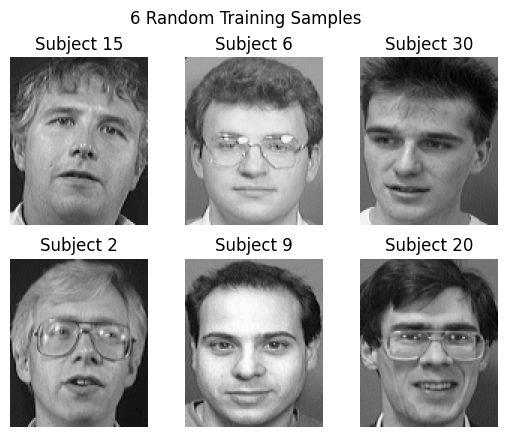

In [3]:
# Set new random seed
random.seed(D+1)

training_files = os.listdir(train_dir)
selected = random.sample(training_files, 6)

# # Display the selected images
fig, axes = plt.subplots(2, 3)

for i in range(6):
    ax = axes[i // 3][i % 3]
    filename = selected[i]

    # Extract subject ID from filename
    subject_id = int(filename.split('_')[0][1:])
    
    # Load image
    img_path = os.path.join(train_dir, filename)
    img = plt.imread(img_path)
    
    # Display image
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Subject {subject_id}")
    ax.axis('off')

plt.suptitle("6 Random Training Samples")
plt.show()

**Text Response:**
1. The subject IDs are correct when compared to the ground truth images. I was able to use the .split function which allowed me to split the filename into the subject id and the index of the image. Since the filename also had teh character "s" before the subject id, I was able to slice this out and then convert the remaining value to an integer.

#### Part C: Build and Visualize the Data Matrix T

Shape of T: (10304, 320)


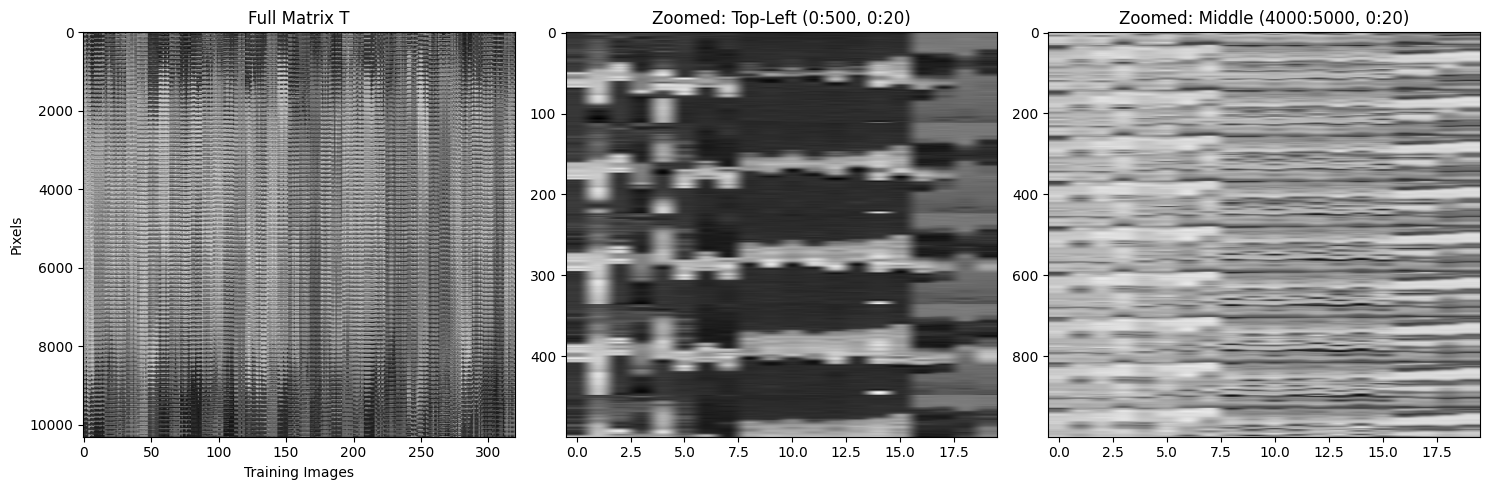

In [29]:
# Go through the training directory and reshape each image into a 1D vector
T = np.zeros((10304, NUM_TRAIN))

for i, filename in enumerate(os.listdir(train_dir)):
    # Open image
    file_path = os.path.join(train_dir, filename)
    img = plt.imread(file_path)

    # Reshape image into a 1D vector and store in T
    T[:, i] = img.flatten(order='F')

# Print the shape of T
print(f"Shape of T: {T.shape}")

# Display Zoomed in versions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Full T
axes[0].imshow(T, cmap='gray', aspect='auto')
axes[0].set_title('Full Matrix T')
axes[0].set_xlabel('Training Images')
axes[0].set_ylabel('Pixels')

# Zoomed region 1: top-left
axes[1].imshow(T[:500, :20], cmap='gray', aspect='auto')
axes[1].set_title('Zoomed: Top-Left (0:500, 0:20)')

# Zoomed region 2: middle
axes[2].imshow(T[4000:5000, :20], cmap='gray', aspect='auto')
axes[2].set_title('Zoomed: Middle (4000:5000, 0:20)')

plt.tight_layout()
plt.show()

**Hand-drawn Diagram:**

![Hand-drawn diagram](./hand_drawn_image/IMG_0487.png)

**Text Response:**
1. Each row of T represents location of pixel across all training images. Each column represents one face flattened into a single vector. T looks unusual as an image because it is not a photo but rather a matrix of data. Since each column is a picture of a face stretched into long strip of pixels, patterns emerge across neighboring pixels that have simiular brightness values.

### Question 2: PCA Analysis
#### Part A: Mean Face
**Text Response:**
1. If the training images are all from the same person, I would expect m to look like a semi-blurred version of that person's face. However, if m is calculated from pictures of 40 different people, I would expect m to look like a very blurry face that is unrecognizable as any specific person.

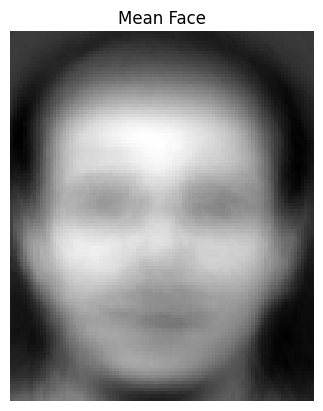

In [5]:
# Compute the mean face
m = np.mean(T, axis=1, keepdims=True)

# Display the face as a 112x92 image
plt.figure()
plt.imshow(m.reshape(112, 92, order='F'), cmap='gray')
plt.title("Mean Face")
plt.axis('off')
plt.show()


**Text Response:**
1. The mean face looks like a blurry image of a balding man. It definitely looks like a plausible face because it has the general features of a human face like ears, eyes, nose, and mouth. But it is very blurry which would make it hard to recognize any specific person from it.

#### Part B: Centered Data Matrix and Covariance

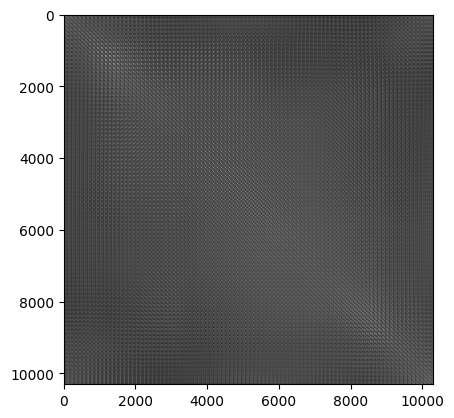

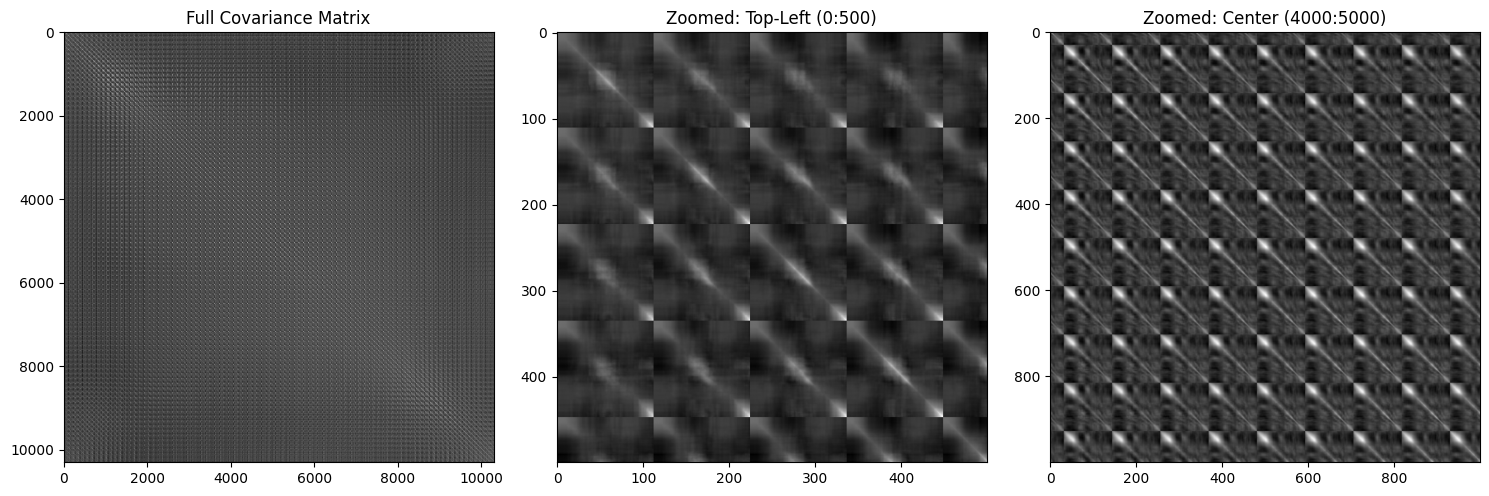

In [ ]:
# Compute A and C
A = T - m
C = A @ A.T

# Display C as a greyscale image
plt.imshow(C, cmap='gray')

# Show zoomed in version
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Full covariance matrix
axes[0].imshow(C, cmap='gray')
axes[0].set_title('Full Covariance Matrix')

# Zoomed region 1: top-left corner
axes[1].imshow(C[:500, :500], cmap='gray')
axes[1].set_title('Zoomed: Top-Left (0:500)')

# Zoomed region 2: center
axes[2].imshow(C[4000:5000, 4000:5000], cmap='gray')
axes[2].set_title('Zoomed: Center (4000:5000)')

plt.tight_layout()
plt.show()

**Text Response:**
1. I see almost like an X, however, the diagonal from the top left to the bottom right is more prominent. It definitely looks symmetric around the diagonal.

#### Part C: Eigenvalue Analysis and Variance Explained

k for 90.0% variance: 99
k for 95.0% variance: 163
k_5: 163
k for 99.0% variance: 266
k for 95.8% variance: 178
k_D: 178


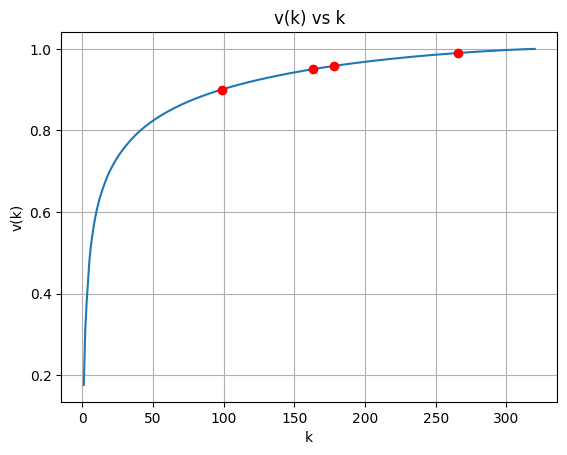

In [7]:
# Compute the eigenvalues
eigenvalues, eigenvectors = np.linalg.eig(A.T @ A)

# Sort the eigenvalues in descending order
indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[indices]
eigenvectors = eigenvectors[:, indices]

# Calculate the variance for varying k up to N
v_k = np.cumsum(eigenvalues) / np.sum(eigenvalues)

# Plot v_k vs k
plt.figure()
plt.plot(range(1, len(v_k) + 1), v_k)
plt.xlabel('k')
plt.ylabel('v(k)')
plt.title('v(k) vs k')
plt.grid()

# Mark points
personal_threshold = (90 + D/10) / 100
for threshold in [0.90, 0.95, 0.99, personal_threshold]:
    k = np.where(v_k >= threshold)[0][0] + 1
    plt.plot(k, threshold, 'ro')
    print(f"k for {threshold*100}% variance: {k}")
    if threshold == 0.95:
        k_5 = k
        print(f"k_5: {k_5}")
    if threshold == personal_threshold:
        k_D = k
        print(f"k_D: {k_D}")
    



**Text Response:**
1. k_5 was equal to 163 and k_D was equal to 178. k_5 is representing 163/10304 is 1.58% of the original dimensions. k_D is representing 178/10304 is 1.73% of the original dimensions. What this means practically is that we are only using less than 2% of the original pixel dimensions while retaining a majority of the variance. This will improve our processing speeds since it will reduce the size of the matrix.

**Pre-computation Check:**

A^T @ A is N_train by N_Train which is 320 x 320 whereas A @ A^T is 10304 x 10304. Both share the same non-zero eigenvalues but A^T @ A is far smaller. This makes computation far faster.

#### Part D: Compute the Eigenfaces

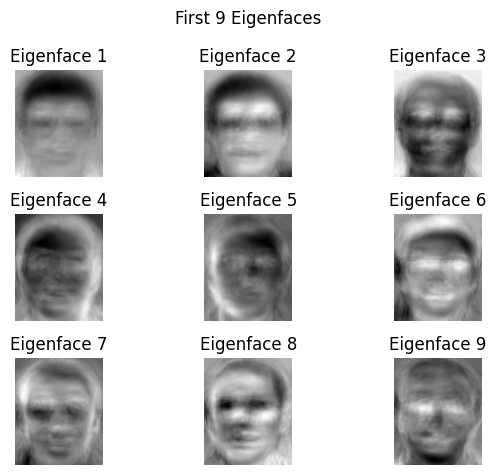

U Shape: (10304, 178)


In [8]:
# Calculate k_D eigenvectors of C
eigenvalues_d, U = eigsh(C, k=k_D)

# Place in descending order
U = U[:, ::-1]
eigenvalues_d = eigenvalues_d[::-1]

# Display the first 9 eigenfaces
fig, axes = plt.subplots(3, 3)
for i in range(9):
    ax = axes[i // 3][i % 3]
    ax.imshow(U[:, i].reshape(112, 92, order='F'), cmap='gray')
    ax.set_title(f'Eigenface {i+1}')
    ax.axis('off')

plt.suptitle('First 9 Eigenfaces')
plt.tight_layout()
plt.show()

# Print out information
print(f"U Shape: {U.shape}")

**Text Response:**
1. The dimensions of U are 10304 x 178 which matches the expected 10304 x k_D
2. The eigenfaces capture the variation across the different faces. The first eigenface has the hair as the mostt dominant feature but as we go through the rest, other features also become domiannt like eyes, facial shape, mouth, and nose.
3. Yes a face can be reconstructed from a few eigenfaces. In order to recreate the face, we can do weighted sum of eigenfaces. The first couple will capture the general features, and the more eigenfaces we add, the sharper the image quality will get.

#### Part E: Reconstruction Quality

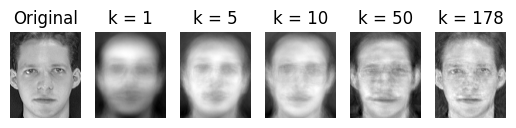

In [9]:
# Pick training image
I = T[:, 0].reshape(-1, 1)

# Define k_values
k_values = [1, 5, 10, 50, k_D]

# Create subplot
fig, axes = plt.subplots(1, 6)

# Display the original
axes[0].imshow(I.reshape(112, 92, order='F'), cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Reconstruct for each k
for i, k in enumerate(k_values):
    U_k = U[:, :k]
    I_reconstructed = m + U_k @ (U_k.T @ (I - m))
    
    axes[i + 1].imshow(I_reconstructed.reshape(112, 92, order='F'), cmap='gray')
    axes[i + 1].set_title(f'k = {k}')
    axes[i + 1].axis('off')

**Text Response:**
1. As k increased, the reconstruction quality improves. The face starts to become recognizable at k = 50 and is mostly recognizable/identical to the original at k = 178.

### Question 3: Feature Extraction
#### Part A: Project Training Images

In [10]:
# Initialize w_train and y_train
W_train = np.zeros((NUM_TRAIN, k_D))
y_train = np.zeros(NUM_TRAIN)

# Loop through images in training set
for i in range(NUM_TRAIN):
    # Get image as column vector
    I = T[:, i].reshape(-1, 1)
    
    # Project onto eigenface space
    w = U.T @ (I - m)

    # Store as a row
    W_train[i, :] = w.flatten()

    # Build y_train
    filename = os.listdir(train_dir)[i]
    subject_id = int(filename.split('_')[0][1:])
    y_train[i] = int(subject_id)

#### Part B: Project Test Images

In [11]:
# Create T_test
T_test = np.zeros((10304, NUM_TEST))

for i, filename in enumerate(os.listdir(test_dir)):
    file_path = os.path.join(test_dir, filename)
    img = plt.imread(file_path)
    T_test[:, i] = img.flatten(order='F')

# Initialize w_test and y_test
W_test = np.zeros((NUM_TEST, k_D))
y_test = np.zeros(NUM_TEST)

# Loop through images in test set
for i in range(NUM_TEST):
    # Get image as column vector
    I = T_test[:, i].reshape(-1, 1)

    # Project onto eigenface space
    w = U.T @ (I - m)

    # Store
    W_test[i, :] = w.flatten()

    # Build y_test
    filename = os.listdir(test_dir)[i]
    subject_id = int(filename.split('_')[0][1:])
    y_test[i] = subject_id

**Text Response:**
1. You would not recompute U or m using test data because it would introduce testing data into the model. This may artificially inflate the accuracy during testing.

#### Part C: Inspect the Feature Space

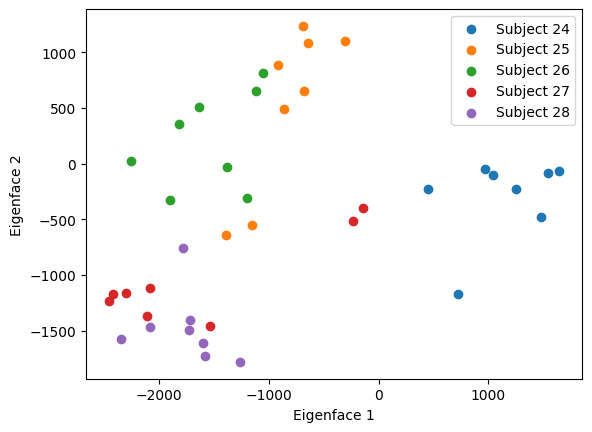

In [12]:
# Define the ids
start = D % 35 + 1
subject_ids = list(range(start, start + 5))

# Create figure
plt.figure()

for subject in subject_ids:
    # Find rows that belong to this subject
    mask = (y_train == subject)

    # Get columns and plot
    plt.scatter(W_train[mask, 0], W_train[mask, 1], label=f'Subject {subject}')

plt.xlabel('Eigenface 1')
plt.ylabel('Eigenface 2')
plt.legend()

**Text Response:**
1. Points from the same subject are generally clustered together. For example, Subject 26 and 24 have their clusters with little to no overlap. However, we do see some points from subject 25 being far away from the general cluster and overlap between subject 27 and 28. This tells us that even two PCA components can capture meaningful discriminatative information between subjects, but two dimensions is not enough to fully seperate everyone.

### Question 4: Face Recognition
#### Part A: KNN Classifier

In [13]:
# Define k_values
k_values = [1, 3, 5, 7, 9, 11, (1 + D % 6) * 2 - 1]

print(f"{'K (neighbors)':<20} {'Test Accuracy (%)':<20}")
print("-" * 40)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(W_train, y_train)
    accuracy = knn.score(W_test, y_test) * 100
    print(f"{k:<20} {accuracy:<20.2f}")

K (neighbors)        Test Accuracy (%)   
----------------------------------------
1                    95.00               
3                    96.25               
5                    90.00               
7                    80.00               
9                    75.00               
11                   75.00               
9                    75.00               


**Text Response:**
1. A k value of 3 gives the best accuracy. Accuracy does not monotonically increase with K. It is observed that at a k value of 1 we see an accuracy of 95% and it increases when k increases to 3 to an accuracy of 96.25%. However, as k increases to 5, 7, 9, and 11, the accuracy drops.
2. Small k value tends to overfit whereas large k values will underfit. We can see this happening where a k value of 1 causes the accuracy to be 95% and as we increase k to 3, it generalizes increasing the accuracy to 96.25% and as it continues to increase past 3, the accuracy drops as the model starts to underfit dropping the accuracy down to 75%.
3. Random chance for 40 subjects in 1/40 which is around 2.5%. So even our worst KNN is better than random guessing. If we used the original images, we would liekly get worse accuracy as KNN struggles in high dimensional spaces. PCA helps in keeping the meaningful information and getting rid of noise which makes distances much more meaningful for KNN.

#### Part B: SVM Classifiers

In [14]:
# Define kernals and strategies
kernels = [
    ('linear', {}),
    ('poly', {'degree': 3}),
    ('rbf', {})
]

strategies = ['ovo', 'ovr']

# Dictionaries for results
time_results = {}
accuracy_results = {}

# Perform loop
for kernel, params in kernels:
    for strategy in strategies:
        svm = SVC(kernel=kernel, C=1.0, decision_function_shape=strategy, **params)
        
        start = time.time()
        svm.fit(W_train, y_train)
        train_time = time.time() - start
        
        accuracy = svm.score(W_test, y_test) * 100
        
        # Store
        time_results[(kernel, strategy)] = train_time
        accuracy_results[(kernel, strategy)] = accuracy

# Print training time table
print(f"{'':30} {'One-vs-One':>15} {'One-vs-All':>15}")
print("-" * 60)
for kernel, params in kernels:
    ovo_time = time_results[(kernel, 'ovo')]
    ovr_time = time_results[(kernel, 'ovr')]
    print(f"{kernel:30} {ovo_time:>14.4f}s {ovr_time:>14.4f}s")

# Print accuracy table
print(f"\n{'':30} {'One-vs-One':>15} {'One-vs-All':>15}")
print("-" * 60)
for kernel, params in kernels:
    ovo_acc = accuracy_results[(kernel, 'ovo')]
    ovr_acc = accuracy_results[(kernel, 'ovr')]
    print(f"{kernel:30} {ovo_acc:>14.2f}% {ovr_acc:>14.2f}%")

                                    One-vs-One      One-vs-All
------------------------------------------------------------
linear                                 0.0150s         0.0140s
poly                                   0.0151s         0.0150s
rbf                                    0.0177s         0.0181s

                                    One-vs-One      One-vs-All
------------------------------------------------------------
linear                                  98.75%          98.75%
poly                                    83.75%          83.75%
rbf                                     97.50%          97.50%


**Text Response:**
1. Linear kernel achieves the highest accuracy. Overall, the one-vs-all strategy is faster to train.
2. With respect to accuracy, the strategy does not make a difference because the accuracies are the same regardless of which strategy was used. Even for training, it's not a huge difference in time so it does not make a big difference there either. This is likely because the classes are well seperated enough in eigenface space that teh strategy does not matter much.
3. Linear SVM and RBF SVM outperformed the KNN. I would recommend Linear SVM because it finds the optimal decision boundaries rather than relying on the distance to its neighbors which therefore makes it more robust.

#### Part C: Effect of K (PCA Dimensions) on Accuracy

K =     5: Accuracy = 77.50%
K =    10: Accuracy = 96.25%
K =    20: Accuracy = 97.50%
K =    50: Accuracy = 98.75%
K =   163: Accuracy = 98.75%
K =   178: Accuracy = 98.75%


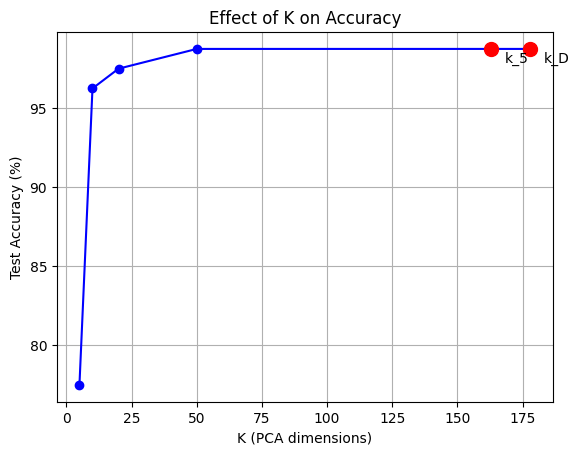

In [25]:
k_values = [5, 10, 20, 50, k_5, k_D]
accuracies = []

for k in k_values:
    # Project using first k eigenfaces
    W_train_k = (U[:, :k].T @ (T - m)).T
    W_test_k = (U[:, :k].T @ (T_test - m)).T

    # Train best classifier (linear SVM)
    svm = SVC(kernel='linear', C=1.0)
    svm.fit(W_train_k, y_train)
    
    accuracy = svm.score(W_test_k, y_test) * 100
    accuracies.append(accuracy)
    print(f"K = {k:>5}: Accuracy = {accuracy:.2f}%")

# Plot
plt.plot(k_values, accuracies, 'b-o')
plt.xlabel('K (PCA dimensions)')
plt.ylabel('Test Accuracy (%)')
plt.title('Effect of K on Accuracy')

# Mark k_5 and k_D
for k, label in [(k_5, 'k_5'), (k_D, 'k_D')]:
    idx = k_values.index(k)
    plt.plot(k, accuracies[idx], 'ro', markersize=10)
    plt.annotate(label, xy=(k, accuracies[idx]), textcoords="offset points", xytext=(10, -10))

plt.grid(True)

**Text Response:**
1. More PCA Components does not necessarily mean better classification accuracy. This is because we can see that teh accuracy rises up until K = 50 but then plateaus after that.
2. There does seem to be an optimal range of K which is aound 50. This is because this is where we see the accuracy peak while using far fewer dimensions. This might be explained by the fact that this may be the point where enough variance id captured to distinguish faces, and anything past this just includes noise.
3. Higher K value means increased training time. Since k = 50 achieves the same level of accuracy as k = 163, and 178, using k = 50 is preferable.